#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [1]:
import time
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split, cross_val_score
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('/datasets/taxi.csv', parse_dates=[0], index_col=0).sort_index()
display(df.head())
display(df.info())
display(df.describe().T)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


None

,count,mean,std,min,25%,50%,75%,max
num_orders,26496.0,14.070463,9.21133,0.0,8.0,13.0,19.0,119.0


In [3]:
df.index.is_monotonic

True

,count,mean,std,min,25%,50%,75%,max
num_orders,4416.0,84.422781,45.023853,0.0,54.0,78.0,107.0,462.0


<AxesSubplot:xlabel='datetime'>

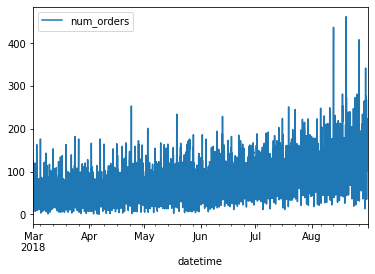

In [4]:
df = df.resample('1H').sum()
df_1 = df.copy()
display(df.describe().T)
display(df.plot())

**Вывод:**
* Были загружены необходимые библиотеки;
* Также изучены данные, временной ряд был задан через индекс;
* Были ресемплированы данные по одному часу.

## Анализ

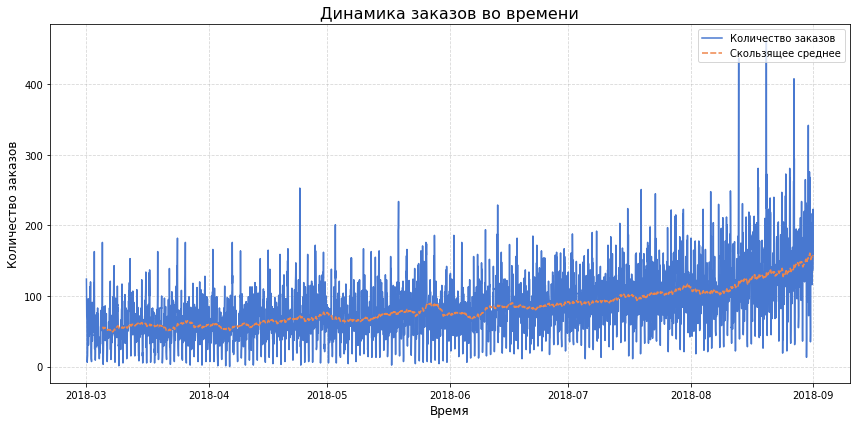

In [5]:
df_1['rolling_mean'] = df_1['num_orders'].rolling(window=100).mean()  
df_1['day_of_week'] = df_1.index.dayofweek
df_1['hour'] = df_1.index.hour

plt.figure(figsize=(12, 6)) 
sns.lineplot(data=df_1[['num_orders', 'rolling_mean']], palette='muted', linewidth=1.5) 

plt.title('Динамика заказов во времени', fontsize=16) 
plt.xlabel('Время', fontsize=12) 
plt.ylabel('Количество заказов', fontsize=12) 

plt.grid(True, linestyle='--', alpha=0.5) 

plt.legend(['Количество заказов', 'Скользящее среднее'], loc='upper right')  

plt.tight_layout()  
plt.show()

*Промежуточный вывод:*  
Наблюдается рост количества заказов с марта 2018 по сентябрь 2018.

In [6]:
data_pivot = pd.pivot_table(df_1, values='num_orders', index='day_of_week', aggfunc='mean')

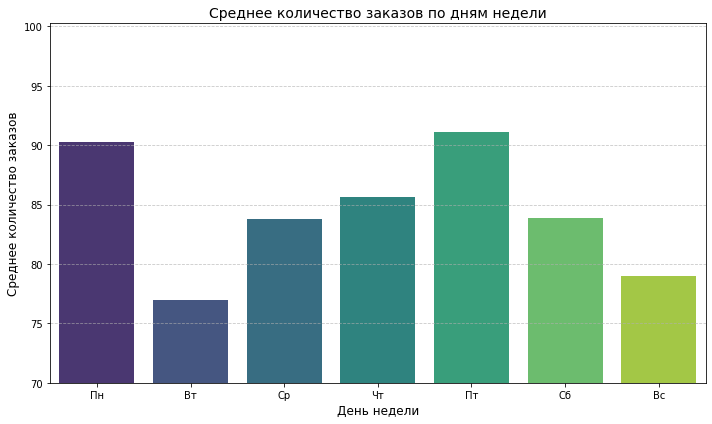

In [7]:
plt.figure(figsize=(10, 6)) 
sns.barplot(x=data_pivot.index, y=data_pivot['num_orders'], palette="viridis") 
plt.title('Среднее количество заказов по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Среднее количество заказов', fontsize=12)
plt.xticks(range(7), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']) 
plt.ylim(70, data_pivot['num_orders'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

*Промежуточный вывод:*  
* В среднем больше всего заказов на такси в пятницу и понедельник;
* В среднем меньше всего заказов на такси во вторник и воскресенье.

In [8]:
data_pivot_1 = pd.pivot_table(df_1, values='num_orders', index='hour', aggfunc='mean')

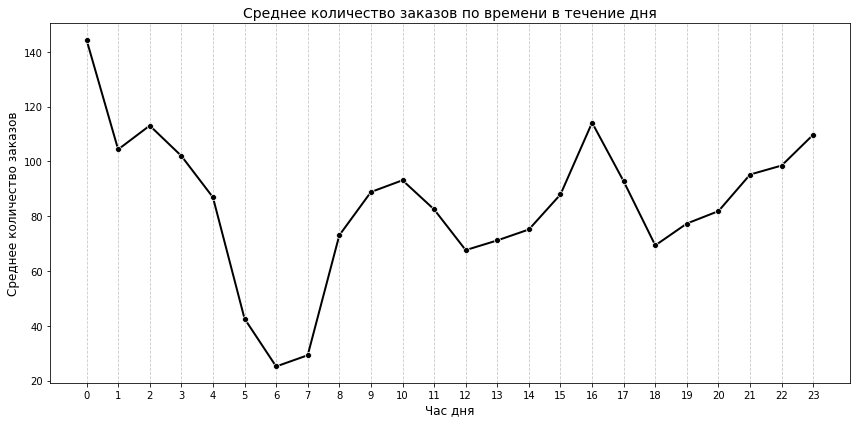

In [9]:
plt.figure(figsize=(12, 6))  
sns.lineplot(x=data_pivot_1.index, y=data_pivot_1['num_orders'], color='black', linewidth=2, marker='o') 
plt.title('Среднее количество заказов по времени в течение дня', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Среднее количество заказов', fontsize=12)
plt.xticks(range(24))  
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*Промежуточный вывод:*
* Такси пользуются чаще всего вечером и ночью, ранним утром меньше всего заказов. Далее пики заказов такси во время того, когда все едут на работу и с работы;
* 18 часов (24 - 06) - это подходящая ширина сдвига, исходя из экстремумов в данных о заказах.

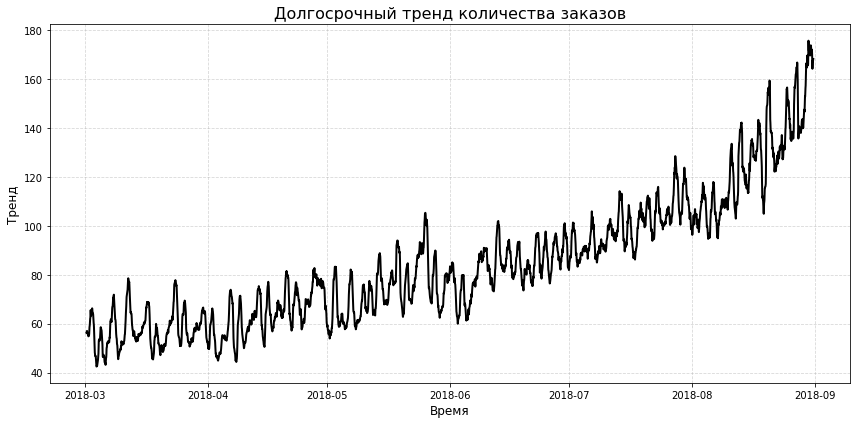

In [10]:
try:
    decomposed = seasonal_decompose(df_1['num_orders'], model='additive', period=24) 
except ValueError as e:
    print(f"Ошибка: {e}.  Убедитесь, что ваши данные содержат достаточное количество периодов.")
    exit()

plt.figure(figsize=(12, 6))
plt.plot(decomposed.trend, color='black', linewidth=2)  
plt.title('Долгосрочный тренд количества заказов', fontsize=16)  
plt.xlabel('Время', fontsize=12)
plt.ylabel('Тренд', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)  
plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
Как определялось раннее присутсвует восходящий тренд количества заказов.

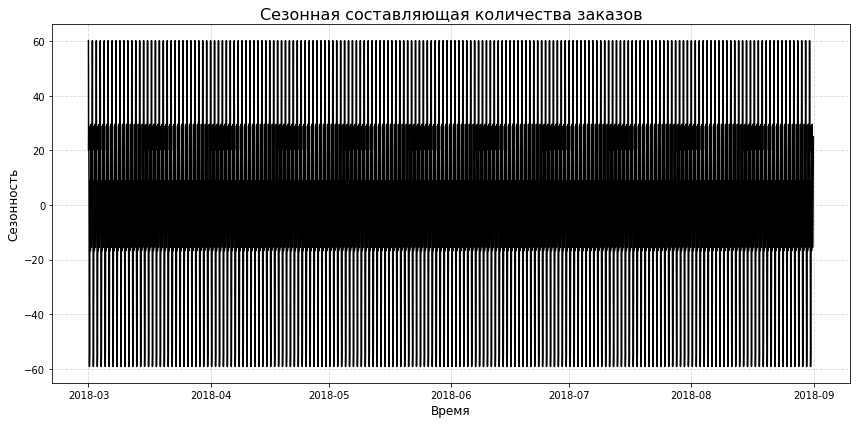

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(decomposed.seasonal, color='black', linewidth=1.5) 
plt.title('Сезонная составляющая количества заказов', fontsize=16)  
plt.xlabel('Время', fontsize=12)
plt.ylabel('Сезонность', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)  
plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
Сезонности в течение рассматриваемого периода нет, только изменения в течении дня. 

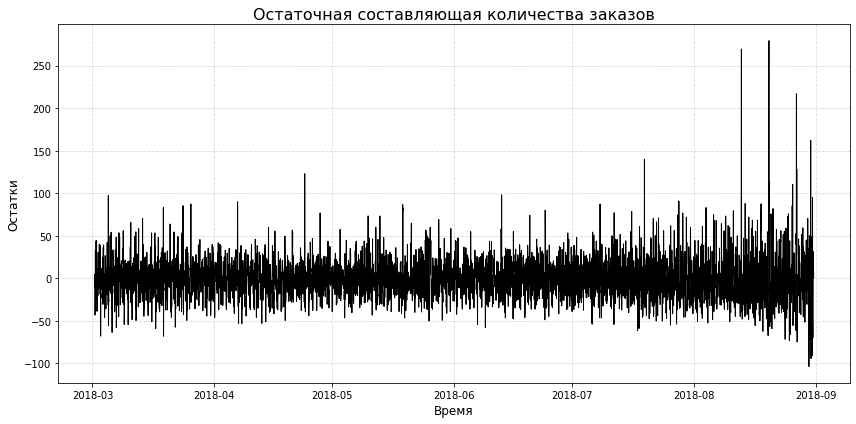

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(decomposed.resid, color='black', linewidth=1)  
plt.title('Остаточная составляющая количества заказов', fontsize=16) 
plt.xlabel('Время', fontsize=12)
plt.ylabel('Остатки', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)  
plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
По остаткам выводов каких любо сделать не получается.

In [13]:
best_rmse = float('inf')  
best_rolling_size = 0

for rolling_size in range(1, 51):  

    temp_data = df_1.copy()

    temp_data['rolling_mean'] = temp_data['num_orders'].shift().rolling(window=rolling_size, min_periods=1).mean()
    temp_data.dropna(inplace=True)

    if len(temp_data) < 2:
        continue

    rmse = mean_squared_error(temp_data['num_orders'], temp_data['rolling_mean']) ** 0.5

    if rmse < best_rmse:
        best_rmse = rmse
        best_rolling_size = rolling_size

if best_rolling_size > 0:
    display(f'RMSE: {best_rmse:.2f}')
    display(f'Размер скользящего окна: {best_rolling_size}')
else:
    display("Не найден допустимый размер.")

'RMSE: 36.87'

'Размер скользящего окна: 26'

**Вывод:**
* Наблюдается рост количества заказов с марта 2018 по сентябрь 2018;
* В среднем больше всего заказов на такси в пятницу и понедельник;
* В среднем меньше всего заказов на такси во вторник и воскресенье;
* Такси пользуются чаще всего вечером и ночью, ранним утром меньше всего заказов. Далее пики заказов такси во время того, когда все едут на работу и с работы;
* 18 часов (24 - 06) - это подходящая ширина сдвига, исходя из экстремумов в данных о заказах;
* Сезонности в течение рассматриваемого периода нет, только изменения в течении дня;
* Размер скользящего окна: 26.

## Обучение

### Создание признаков

In [14]:
BEST_LAG = 18

df_2 = df_1.copy()
df_2['hour'] = df_2.index.hour
df_2['month'] = df_2.index.month
df_2['day'] = df_2.index.day
df_2['dayofweek'] = df_2.index.dayofweek

for lag in range(1, BEST_LAG + 1):
    df_2[f'lag_{lag}'] = df_2['num_orders'].shift(lag)

df_2['rolling_mean'] = df_2['num_orders'].shift().rolling(best_rolling_size).mean()
df_2.dropna(inplace=True)
display(df_2.head())

,num_orders,rolling_mean,day_of_week,hour,month,day,dayofweek,lag_1,lag_2,lag_3,...,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 02:00:00,75,60.538462,4,2,3,2,4,120.0,90.0,58.0,...,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0,34.0
2018-03-02 03:00:00,64,58.653846,4,3,3,2,4,75.0,120.0,90.0,...,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0,69.0
2018-03-02 04:00:00,20,57.846154,4,4,3,2,4,64.0,75.0,120.0,...,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0,64.0
2018-03-02 05:00:00,11,55.884615,4,5,3,2,4,20.0,64.0,75.0,...,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0,96.0
2018-03-02 06:00:00,11,53.769231,4,6,3,2,4,11.0,20.0,64.0,...,66.0,61.0,45.0,73.0,44.0,43.0,66.0,48.0,32.0,30.0


### Деление на выборки

In [15]:
train, test = train_test_split(df_2, shuffle=False, test_size=0.1, random_state=42)

target_train = train['num_orders']
features_train = train.drop('num_orders', axis=1)

target_test = test['num_orders']
features_test = test.drop('num_orders', axis=1)

display(f'Выборка разделена в пропорциях:')
display(f'{(len(features_train)/len(df_2)):.0%} — тренировочная;')
display(f'{(len(features_test)/len(df_2)):.0%} — тестовая.')

'Выборка разделена в пропорциях:'

'90% — тренировочная;'

'10% — тестовая.'

### Функция для вычисления RMSE и доп. параметры

In [16]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

In [17]:
RANDOM_STATE = 42
CV = 3
models_compare = {}

### RandomForestRegressor

In [18]:
start_time = time.time()  

model = RandomForestRegressor(random_state=RANDOM_STATE)
parameters = {
    'n_estimators': [25, 30, 35, 38, 39, 40, 45],  
    'max_depth': [14, 15, 16, 17, 18],
}
rf_grid = GridSearchCV(model, parameters, cv=TimeSeriesSplit(n_splits=CV), n_jobs=-1, scoring='neg_mean_squared_error')
rf_grid.fit(features_train, target_train)

rf_fit_time = time.time() - start_time

display("Найдены лучшие параметры:")
display(rf_grid.best_params_)

rf_rmse = np.sqrt(-rf_grid.best_score_)

start_predict_time = time.time() 
rf_predictions = rf_grid.predict(features_train)
rf_predict_time = time.time() - start_predict_time 

models_compare['RandomForestRegressor'] = {
    'fit_time': rf_fit_time,
    'predict_time': rf_predict_time,
    'rmse': rf_rmse
}

'Найдены лучшие параметры:'

{'max_depth': 17, 'n_estimators': 45}

### CatBoostRegressor

In [19]:
start_time = time.time()

regressor = CatBoostRegressor(learning_rate=0.5,
                              iterations=200,
                              random_state=42,
                              verbose=False)

cv_results = cross_val_score(regressor,
                                features_train, 
                                target_train,
                                cv=TimeSeriesSplit(n_splits=CV), 
                                scoring='neg_mean_squared_error')

cat_fit_time = time.time() - start_time

cat_rmse = (cv_results.mean() * -1) ** 0.5 


start_time_predict = time.time()

regressor.fit(features_train, target_train, verbose=False) 

predictions = regressor.predict(features_train) 

end_time_predict = time.time()
cat_predict_time = end_time_predict - start_time_predict

models_compare['CatBoostRegressor'] = {
    'fit_time': cat_fit_time,
    'predict_time': cat_predict_time,
    'rmse': cat_rmse
}

### LGBMRegressor

In [20]:
start_time = time.time()

model = LGBMRegressor(random_state=RANDOM_STATE)
parameters = {
    'max_depth': [5, 8, 10], 
    'num_leaves': [10, 50, 100],
    'learning_rate': [0.1, 0.5, 1],
}
lgbm_grid = GridSearchCV(model, parameters, cv=TimeSeriesSplit(n_splits=CV), n_jobs=-1, scoring='neg_mean_squared_error')
lgbm_grid.fit(features_train, target_train)

lgbm_fit_time = time.time() - start_time

display("Найдены лучшие параметры:")
display(lgbm_grid.best_params_)

lgbm_rmse = np.sqrt(-lgbm_grid.best_score_)

start_predict_time = time.time()
lgbm_predictions = lgbm_grid.predict(features_train)
lgbm_predict_time = time.time() - start_predict_time

models_compare['LGBMRegressor'] = {
    'fit_time': lgbm_fit_time,
    'predict_time': lgbm_predict_time,
    'rmse': lgbm_rmse
}

'Найдены лучшие параметры:'

{'learning_rate': 0.1, 'max_depth': 8, 'num_leaves': 50}

### LinearRegression

In [22]:
categorical_features = ['hour', 'dayofweek']

encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)  
encoder.fit(features_train[categorical_features])

encoded_train = encoder.transform(features_train[categorical_features])
encoded_test = encoder.transform(features_test[categorical_features])

feature_names = []
for feature in categorical_features:
    num_categories = len(features_train[feature].unique())
    feature_names.extend([f'{feature}_{i}' for i in range(num_categories)])

encoded_train_df = pd.DataFrame(encoded_train, columns=feature_names, index=features_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=feature_names, index=features_test.index)

features_train_1 = pd.concat([features_train.drop(categorical_features, axis=1), encoded_train_df], axis=1)
features_test_1 = pd.concat([features_test.drop(categorical_features, axis=1), encoded_test_df], axis=1)

In [23]:
start_time = time.time()

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

linear_cv_scores = cross_val_score(pipeline, features_train_1, target_train, cv=TimeSeriesSplit(n_splits=CV), scoring='neg_mean_squared_error')

linear_fit_time = time.time() - start_time

linear_rmse = np.sqrt(-linear_cv_scores.mean())

start_predict_time = time.time()
pipeline.fit(features_train_1, target_train)
linear_predictions = pipeline.predict(features_train_1)
linear_predict_time = time.time() - start_predict_time

models_compare['LinearRegression'] = {
    'fit_time': linear_fit_time,
    'predict_time': linear_predict_time,
    'rmse': linear_rmse
}

In [24]:
models_statistics = pd.DataFrame(models_compare).T
display(models_statistics)

,fit_time,predict_time,rmse
RandomForestRegressor,85.310776,0.038888,27.557692
CatBoostRegressor,5.038667,1.794700,29.075995
LGBMRegressor,234.713456,0.097271,27.161620
LinearRegression,0.690794,0.300647,26.532327


**Вывод:**  
Самый лучший результат у LGBMRegressor, на нём и будем тестировать.

## Тестирование

In [25]:
start_time_predict = time.time()
predictions = lgbm_grid.best_estimator_.predict(features_test)
prediction_time = time.time() - start_time_predict

lgbm_rmse = mean_squared_error(target_test, predictions) ** 0.5

display(f"Время предсказания LGBMRegressor: {prediction_time:.4f} секунд")
display(f"RMSE LGBMRegressor: {lgbm_rmse:.4f}")

'Время предсказания LGBMRegressor: 0.0127 секунд'

'RMSE LGBMRegressor: 41.8296'

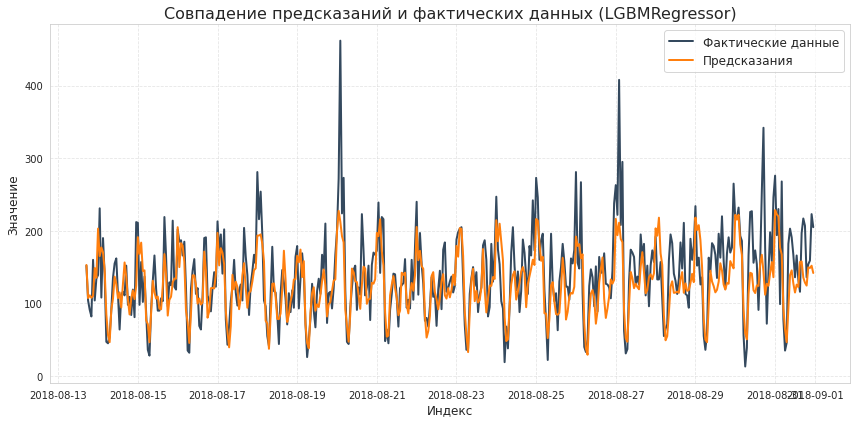

In [26]:
plt.figure(figsize=(12, 6)) 
sns.set_style("whitegrid")  

actual_color = "#34495e"
predicted_color = "#ff7f0e"

sns.lineplot(data=target_test, label='Фактические данные', linewidth=2, color=actual_color)
sns.lineplot(x=target_test.index, y=predictions, label='Предсказания', linewidth=2, color=predicted_color)

plt.title('Совпадение предсказаний и фактических данных (LGBMRegressor)', fontsize=16)
plt.xlabel('Индекс', fontsize=12)
plt.ylabel('Значение', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Вывод:**  
Выбранная модель (*LGBMRegressor*) прошла по условию проекта RMSE = 41.8296 < 48.

## Общие выводы

* Были загружены необходимые библиотеки;
* Также изучены данные, временной ряд был задан через индекс;
* Были ресемплированы данные по одному часу.

Анализ:
* Наблюдается рост количества заказов с марта 2018 по сентябрь 2018;
* В среднем больше всего заказов на такси в пятницу и понедельник;
* В среднем меньше всего заказов на такси во вторник и воскресенье;
* Такси пользуются чаще всего вечером и ночью, ранним утром меньше всего заказов. Далее пики заказов такси во время того, когда все едут на работу и с работы;
* 18 часов (24 - 06) - это подходящая ширина сдвига, исходя из экстремумов в данных о заказах;
* Сезонности в течение рассматриваемого периода нет, только изменения в течении дня;
* Размер скользящего окна: 26.

Обучение:	
- RandomForestRegressor	RMSE = 27.557692
- CatBoostRegressor	RMSE = 27.649979
- LGBMRegressor	RMSE = 27.161620
- LinearRegression RMSE = 31.045658

Самый лучший результат у LGBMRegressor, на нём и будем тестировать.

Выбранная модель (*LGBMRegressor*) прошла по условию проекта **RMSE = 41.8296 < 48**.

Выполнил Лосевский Дмитрий